<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/05_1_exploratory_data_analysis_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) - MNIST Dataset
The MNIST dataset is a clean, well-balanced, and standardized dataset. The primary challenge for a model is to learn the spatial patterns of pixel activations that define each of the 10 digits.

This example perform a detailed Exploratory Data Analysis (EDA) on the MNIST dataset of handwritten digits. The goal of EDA is to systematically analyzes the dataset's fundamental properties to uncover patterns, check assumptions, and gain insights before any machine learning model is built.

All plots saved to the '{OUTPUT_DIR}' directory.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Configuration ---
OUTPUT_DIR = "mnist_deep_eda_output_procedural"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

In [2]:
# --- 1. Data Loading ---
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("✓ Data loaded successfully.")
print(f"  Training data shape: {x_train.shape}")
print(f"  Training labels shape: {y_train.shape}")

Loading MNIST dataset...
✓ Data loaded successfully.
  Training data shape: (60000, 28, 28)
  Training labels shape: (60000,)


## Univariate Findings
Univariate analysis focuses on a single variable. Its main goal is to describe the data and find patterns within that one variable.

1. Class Balance: The dataset is highly balanced. Each digit (0-9) constitutes approximately 10% of the training data, ensuring that a model won't be biased towards a specific digit due to frequency.
2. Pixel Intensity: The vast majority of pixels have an intensity of 0 (black). This is expected, as each digit is drawn on a black background. The non-zero pixel values, representing the handwritten strokes, are less frequent, which is clearly visible on the log-scale histogram.


--- Starting Univariate Analysis ---
Analyzing label distribution...


/tmp/ipython-input-3-3401857865.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train, palette="viridis")


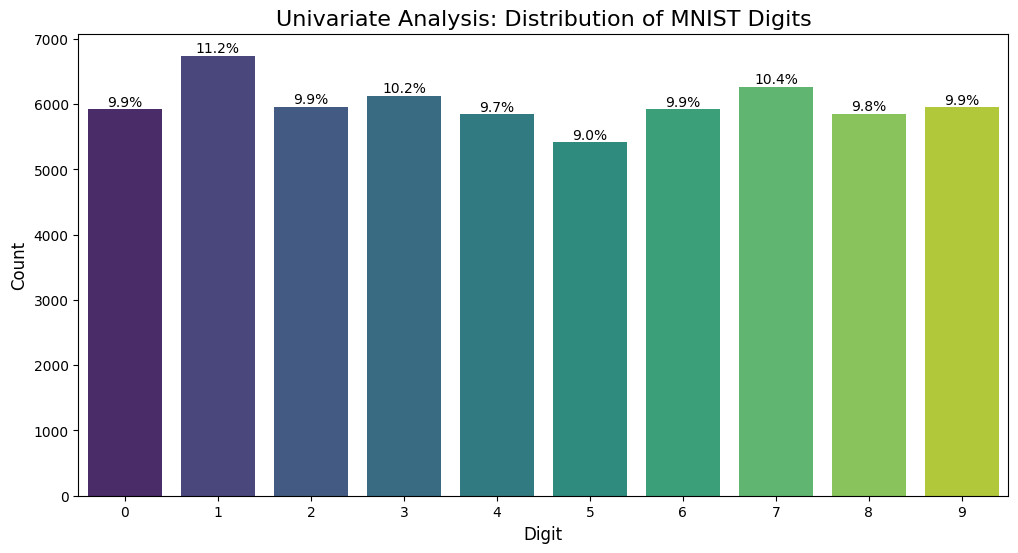

✓ Label distribution plot saved.
Analyzing pixel intensity distribution...


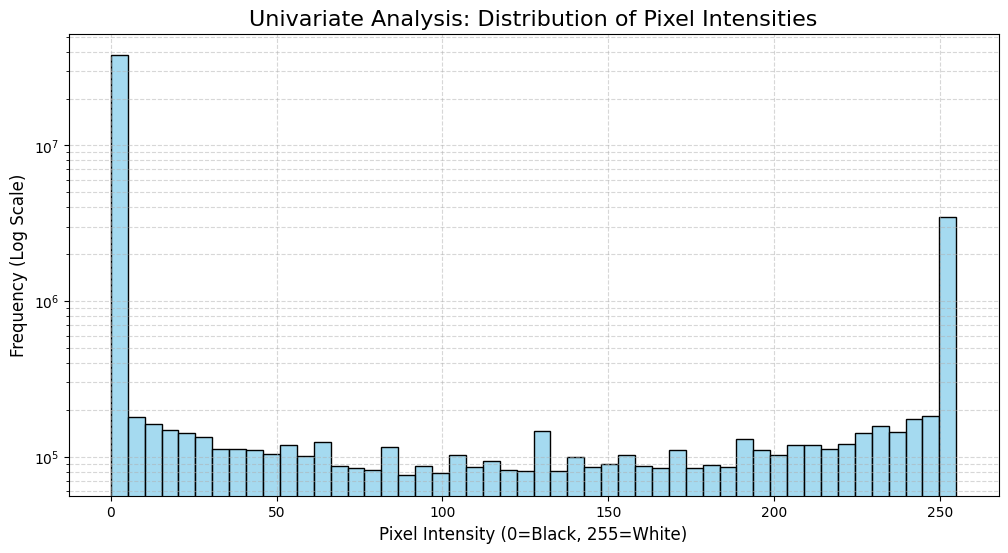

✓ Pixel intensity distribution plot saved.
--- Univariate Analysis Complete ---


In [3]:
# --- 2. Univariate Analysis ---
print("\n--- Starting Univariate Analysis ---")

# a) Analyze the distribution of labels (Digits 0-9)
print("Analyzing label distribution...")
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=y_train, palette="viridis")
plt.title("Univariate Analysis: Distribution of MNIST Digits", fontsize=16)
plt.xlabel("Digit", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add percentage annotations to the bars
total = len(y_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.savefig(os.path.join(OUTPUT_DIR, "1_univariate_label_distribution.png"))
plt.show()
plt.close()
print("✓ Label distribution plot saved.")

# b) Analyze the distribution of pixel values
print("Analyzing pixel intensity distribution...")
plt.figure(figsize=(12, 6))
sns.histplot(x_train.flatten(), bins=50, color='skyblue', kde=False)
plt.title("Univariate Analysis: Distribution of Pixel Intensities", fontsize=16)
plt.xlabel("Pixel Intensity (0=Black, 255=White)", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)
plt.yscale('log')  # Use log scale to better see non-zero pixels
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig(os.path.join(OUTPUT_DIR, "2_univariate_pixel_distribution.png"))
plt.show()
plt.close()
print("✓ Pixel intensity distribution plot saved.")
print("--- Univariate Analysis Complete ---")

## Bivariate Findings
Bivariate analysis explores the relationship between two different variables. Its purpose is to determine if there is a connection, or correlation, between them.

1. Pixel-Class Correlation: The "average image" for each digit reveals a strong correlation between pixel locations and the digit's class. For example:
- The average '1' has a strong vertical activation in the center.
- The average '0' and '8' show clear circular patterns, with the '8' having a distinct intersection in the middle.
- The average '7' shows a strong horizontal line at the top and a diagonal line downwards.

2. Inherent Separability: These distinct average patterns suggest that the classes are linearly separable to a large extent. This explains why even simple models can achieve high accuracy on MNIST. The unique "pixel signature" of each digit is the primary feature that machine learning models will learn.


--- Starting Bivariate Analysis ---
Analyzing relationship between pixel location and digit class...


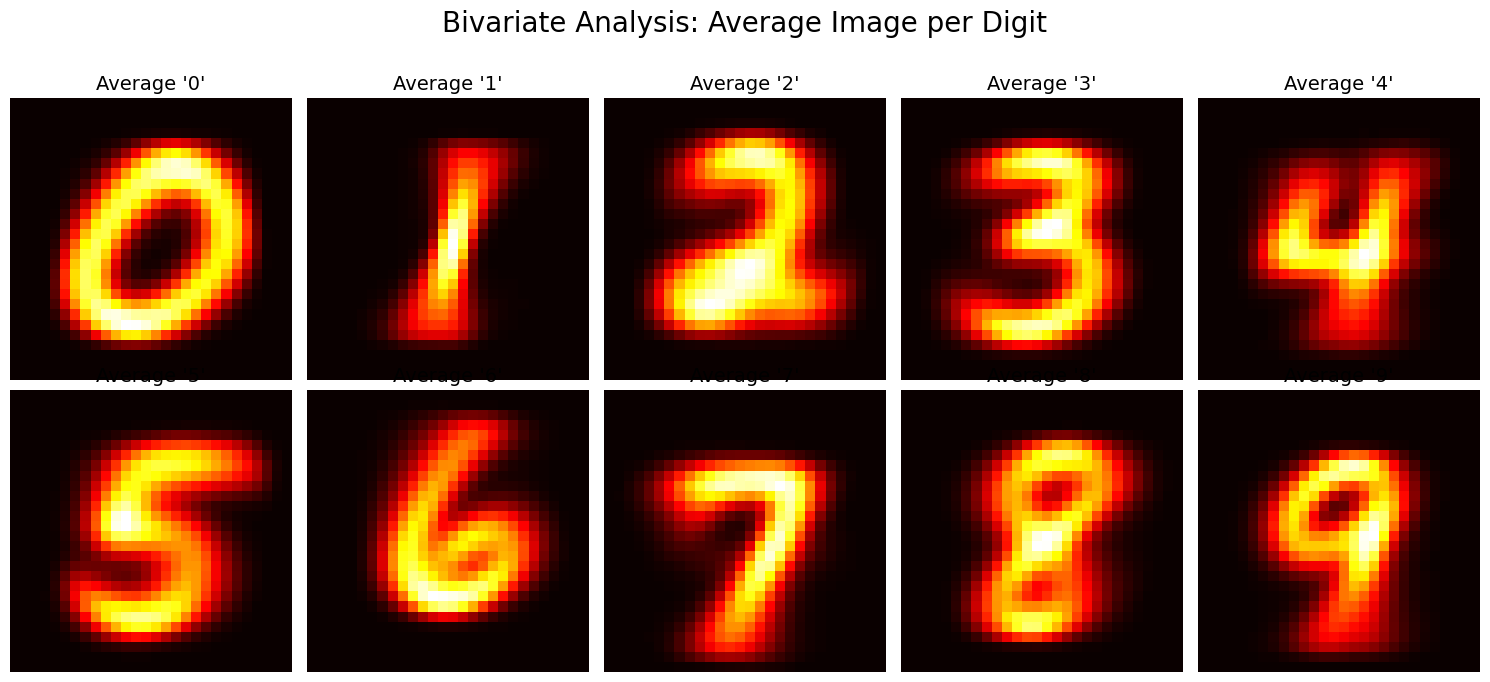

✓ Average digit images plot saved.
--- Bivariate Analysis Complete ---


In [4]:
# --- 3. Bivariate Analysis ---
print("\n--- Starting Bivariate Analysis ---")
print("Analyzing relationship between pixel location and digit class...")

# Calculate and plot the average image for each digit
plt.figure(figsize=(15, 7))
plt.suptitle("Bivariate Analysis: Average Image per Digit", fontsize=20)

for i in range(10):  # For each digit from 0 to 9
    # Filter all images that match the current digit
    digit_images = x_train[y_train == i]

    # Calculate the mean of these images
    mean_image = np.mean(digit_images, axis=0)

    # Plot the mean image
    plt.subplot(2, 5, i + 1)
    plt.imshow(mean_image, cmap='hot')
    plt.title(f"Average '{i}'", fontsize=14)
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUTPUT_DIR, "3_bivariate_average_digits.png"))
plt.show()
plt.close()
print("✓ Average digit images plot saved.")
print("--- Bivariate Analysis Complete ---")